In [1]:
import os; os.chdir("/home/sebastiaan/phd/repositories/immune_response_detection/")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import networkx as nx
from scipy.stats import mannwhitneyu

from clustcrdist.constants.modules.olga import load_model
from clustcrdist.constants.modules.olga import generation_probability as pgen
from clustcrdist.constants.modules.olga import sequence_generation as seq_gen
from clustcrdist.constants.parsing import parse_yfv_repertoires
from clustcrdist.neighbors import neighbor_retrieval, neighbor_dict_to_df
from clustcrdist.indexing import FlatIndex
from clustcrdist.encoding import TCRDistEncoder

from clustcrdist.constants.parsing import _is_cdr3
from clustcrdist.constants.datasets import load_vdjdb

from statsmodels.stats.multitest import multipletests

## **Annotate YFV results with VDJdb data**
### Load the VDJdb and write annotation functions

In [4]:
vdjdb = load_vdjdb()
vdjdb["antigen_epitope"] = vdjdb.antigen_epitope + " (" + vdjdb.antigen_species + ")"
vdjdb["clone"] = vdjdb.v_call + '_' + vdjdb.junction_aa

encoder = TCRDistEncoder(aa_dim=16, vgene_col='v_call', cdr3_col='junction_aa').fit()
index = FlatIndex(encoder=encoder)
index.add(vdjdb)

vdjdb_annotations = dict(vdjdb.groupby("clone").antigen_epitope.unique())
for i in vdjdb_annotations:
    vdjdb_annotations[i] = list(vdjdb_annotations[i])
vdjdb_annotations

def annotate_vdjdb(data, vdjdb_index, vdjdb_annotations, r=24.5):
    '''
    Use neighbor retrieval to fin fuzzy matches with epitope-specific TCRs from the VDJdb database.
    '''

    neighbors = neighbor_retrieval(query=data, encoder=encoder, background=vdjdb_index, drop_zero_neighbor=False, d=r)

    annotations = dict()
    for i in neighbors:
        epitopes = []
        for j in neighbors[i][3]:
            epitopes += vdjdb_annotations[j]
        epitopes = set(epitopes)
        if len(epitopes) > 0:
            annotations['_'.join(i)] = epitopes
        else:
            annotations['_'.join(i)] = None

    data["annotation"] = annotations.values()
    return data, annotations

def parse_responding(df):
    '''
    Load and parse the YFV responding TCRs.
    '''
    old_cols = ["CDR3.nucleotide.sequence","bestVGene","bestJGene","CDR3.amino.acid.sequence","donor"]
    new_cols = ["junction","v_call","j_call","junction_aa","donor"]
    df = df[old_cols]
    df.columns = new_cols
    df["v_call"] = df["v_call"] + "*01" # Add allele
    df["j_call"] = df["j_call"] + "*01" # Add allele
    df["clone"] = df["v_call"] + "_" + df["junction_aa"] # Make clone col
    return df

def merge_responding(data, donor):
    '''
    Merge the YFV responding TCRs with SNE clones.
    '''

    responding = pd.read_table("../sne_manuscript/data/yfv_responding.txt")
    responding = parse_responding(responding)
    responding = responding[responding.donor==donor]

    responding["responding"] = True
    sign = data.merge(responding, on=["v_call","junction_aa"], how="left")
    if "junction_x" in sign.columns:
        sign = sign.drop(columns=["junction_x","j_call_x"])
    else:
        sign = sign.drop(columns=["junction","j_call","donor"])
    sign["responding"] = sign.responding.fillna(False)
    sign['annotation'] = sign.annotation.astype(str)
    sign['clone'] = sign.v_call + '_' + sign.junction_aa
    sign = sign.drop_duplicates()

    return sign

### Perform the annotation

In [5]:
responding = pd.read_table("../sne_manuscript/data/yfv_responding.txt")
responding = parse_responding(responding)
# responding = responding[responding.donor==donor] # if looking at a specific donor

files = ['Q1_15_F1_.txt.gz',
 'P2_15_F1_.txt.gz',
 'Q2_15_F1_.txt.gz',
 'S1_15_F1_.txt.gz',
 'S2_15_F1_.txt.gz',
 'P1_15_F1_.txt.gz']

df_all = []
for file in files:
    df = pd.read_table(f'../sne_manuscript/analysis/yfv/updated/{file}')
    df['pval_corr'] = multipletests(df.pval, method='bonferroni')[1]
    df = df[df.pval_corr<.05]
    df['file'] = file
    df_all.append(df)
df_all = pd.concat(df_all)

shared_sne = df_all.groupby(['junction_aa','v_call']).file.nunique().sort_values(ascending=False).reset_index()
shared_res = responding.groupby(['junction_aa','v_call']).donor.nunique().sort_values(ascending=False).reset_index()
# shared_sne = shared_sne[shared_sne.file>1]
# shared_res = shared_res[shared_res.donor>1]
shared_sne.columns = ['junction_aa','v_call','sne_shared']
shared_res.columns = ['junction_aa','v_call','res_shared']
shared = shared_sne.merge(shared_res, on=['junction_aa','v_call'], how='outer').fillna(0)

shared = shared[shared[['sne_shared','res_shared']].sum(axis=1)>1]
shared = shared.reset_index(drop=True)

shared['clone'] = shared.junction_aa + '_' + shared.v_call
shared_res = shared_res[shared_res.junction_aa.apply(lambda x: _is_cdr3(x))]

res_annotated, _ = annotate_vdjdb(data=shared_res, vdjdb_index=index, vdjdb_annotations=vdjdb_annotations)
sne_annotated, _ = annotate_vdjdb(data=shared_sne, vdjdb_index=index, vdjdb_annotations=vdjdb_annotations)

/tmp/ipykernel_2367745/1215872643.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["v_call"] = df["v_call"] + "*01"
/tmp/ipykernel_2367745/1215872643.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["j_call"] = df["j_call"] + "*01"
/tmp/ipykernel_2367745/1215872643.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/

encoding query sequences
searching for neighbors
Combining results
encoding query sequences
searching for neighbors
Combining results


### Combine results and plot

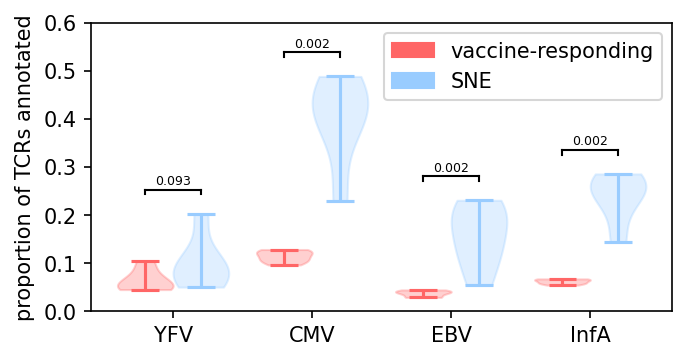

In [19]:
# Select specific viruses
annotation_results = []
species = ['YFV','CMV','EBV','InfluenzaA']

responding = responding[responding.junction_aa.apply(lambda x: _is_cdr3(x))]
res_all = responding.merge(res_annotated, on=['junction_aa','v_call'])
sne_all = df_all.merge(sne_annotated, on=['junction_aa','v_call'])
donors = ['P1','P2','Q1','Q2','S1','S2']
for sp in species:
    for donor in donors:
        donor_df = res_all[res_all.donor==donor]
        total = donor_df.shape[0]
        count = donor_df.annotation.astype(str).str.contains(sp).sum()
        annotation_results.append((sp,donor,count/total,'vaccine-responding'))
    for donor in donors:
        donor_df = sne_all[sne_all.file==f'{donor}_15_F1_.txt.gz']
        total = donor_df.shape[0]
        count = donor_df.annotation.astype(str).str.contains(sp).sum()
        annotation_results.append((sp,donor,count/total,'SNE'))

# Summarize results
annotation_results = pd.DataFrame(annotation_results, columns=['species','donor','frequency','category'])

# Plotting
fig, ax = plt.subplots(dpi=150, figsize=(5, 2.5))

# Function to add violin plots for each virus and category
def add_violin_plot(species_data, position, color):
    parts = ax.violinplot(species_data['frequency'], positions=[position])
    parts['bodies'][0].set_facecolor(color)
    parts['bodies'][0].set_edgecolor(color)
    parts['cbars'].set_color(color)
    parts['cmins'].set_color(color)
    parts['cmaxes'].set_color(color)

# Colors for categories
colors = {'vaccine-responding': (1.0, 0.4, 0.4), 'SNE': (0.6, 0.8, 1.0)}

# Add violins
xticks = [0, 1.25, 2.5, 3.75]
for i, sp in enumerate(species):
    sp_data = annotation_results[annotation_results.species == sp]
    add_violin_plot(sp_data[sp_data['category'] == 'vaccine-responding'], xticks[i] - 0.25, colors['vaccine-responding'])
    add_violin_plot(sp_data[sp_data['category'] == 'SNE'], xticks[i] + 0.25, colors['SNE'])

# Adding p-value annotations
# vv
species_data = {
    'YFV': {'data': yfv, 'position': 0},
    'CMV': {'data': cmv, 'position': 1.25},
    'EBV': {'data': ebv, 'position': 2.5},
    'InfluenzaA': {'data': ifa, 'position': 3.75},
}

# Loop through species data and perform plotting
for sp, info in species_data.items():
    data = info['data']
    x_pos = info['position']
    maxfreq = data.frequency.max()

    # Plot horizontal line and vertical connectors for significance testing
    ax.plot([x_pos - 0.25, x_pos + 0.25], [maxfreq + 0.05, maxfreq + 0.05], c='black', lw=1)
    ax.plot([x_pos - 0.25, x_pos - 0.25], [maxfreq + 0.04, maxfreq + 0.05], c='black', lw=1)
    ax.plot([x_pos + 0.25, x_pos + 0.25], [maxfreq + 0.04, maxfreq + 0.05], c='black', lw=1)

    # Perform statistical test and annotate
    a = data[data['category'] == 'vaccine-responding'].frequency
    b = data[data['category'] == 'SNE'].frequency
    _, p = mannwhitneyu(a, b)
    ax.text(x=x_pos, y=maxfreq + 0.06, s=f'{p:.3f}', ha='center', fontsize=6)

# Set labels
xticks = [0,1.25,2.5,3.75]
ax.set_xticks(xticks)
ax.set_xticklabels(['YFV','CMV','EBV','InfA'])
ax.set_ylim(0,.6)
ax.set_ylabel('proportion of TCRs annotated')

# Legend
vaccine_patch = mpatches.Patch(color=colors['vaccine-responding'], label='vaccine-responding')
sne_patch = mpatches.Patch(color=colors['SNE'], label='SNE')
ax.legend(handles=[vaccine_patch, sne_patch], loc='upper right')


In [2]:
donor = "S1"

sne_15 = pd.read_table(f"../sne_manuscript/analysis/yfv/updated/{donor}_15_F1_.txt.gz")
rep = parse_yfv_repertoires(f"../sne_manuscript/data/yfv/{donor}_15_F1_.txt.gz", count=1)
sne_15["eval"] = rep.shape[0] * sne_15.pval
rep_15_size = rep.shape[0]
sne_15["p_bf"] = multipletests(sne_15['pval'], method='bonferroni')[1]
sne_15["p_bh"] = multipletests(sne_15['pval'], method='fdr_bh')[1]

sne_0 = pd.read_table(f"../sne_manuscript/analysis/yfv/updated/{donor}_0_F1_.txt.gz")
rep = parse_yfv_repertoires(f"../sne_manuscript/data/yfv/{donor}_0_F1_.txt.gz", count=1)
rep_0_size = rep.shape[0]
sne_0["eval"] = rep.shape[0] * sne_0.pval
sne_0["p_bf"] = multipletests(sne_0['pval'], method='bonferroni')[1]
sne_0["p_bh"] = multipletests(sne_0['pval'], method='fdr_bh')[1]

sne_7 = pd.read_table(f"../sne_manuscript/analysis/yfv/updated/{donor}_7_F1_.txt.gz")
rep = parse_yfv_repertoires(f"../sne_manuscript/data/yfv/{donor}_7_F1_.txt.gz", count=1)
sne_7["eval"] = rep.shape[0] * sne_7.pval
rep_7_size = rep.shape[0]
sne_7["p_bf"] = multipletests(sne_7['pval'], method='bonferroni')[1]
sne_7["p_bh"] = multipletests(sne_7['pval'], method='fdr_bh')[1]

sne_45 = pd.read_table(f"../sne_manuscript/analysis/yfv/updated/{donor}_45_F1_.txt.gz")
rep = parse_yfv_repertoires(f"../sne_manuscript/data/yfv/{donor}_45_F1_.txt.gz", count=1)
rep_45_size = rep.shape[0]
sne_45["eval"] = rep.shape[0] * sne_45.pval
sne_45["p_bf"] = multipletests(sne_45['pval'], method='bonferroni')[1]
sne_45["p_bh"] = multipletests(sne_45['pval'], method='fdr_bh')[1]

In [5]:
results = {}

donor = "Q2"

sne_0 = pd.read_table(f"../sne_manuscript/analysis/yfv/updated/{donor}_0_F1_.txt.gz")
sne_0["p_bf"] = multipletests(sne_0['pval'], method='bonferroni')[1]
sne_0["p_bh"] = multipletests(sne_0['pval'], method='fdr_bh')[1]

sne_7 = pd.read_table(f"../sne_manuscript/analysis/yfv/updated/{donor}_7_F1_.txt.gz")
sne_7["p_bf"] = multipletests(sne_7['pval'], method='bonferroni')[1]
sne_7["p_bh"] = multipletests(sne_7['pval'], method='fdr_bh')[1]

sne_15 = pd.read_table(f"../sne_manuscript/analysis/yfv/updated/{donor}_15_F1_.txt.gz")
sne_15["p_bf"] = multipletests(sne_15['pval'], method='bonferroni')[1]
sne_15["p_bh"] = multipletests(sne_15['pval'], method='fdr_bh')[1]

sne_45 = pd.read_table(f"../sne_manuscript/analysis/yfv/updated/{donor}_45_F1_.txt.gz")
sne_45["p_bf"] = multipletests(sne_45['pval'], method='bonferroni')[1]
sne_45["p_bh"] = multipletests(sne_45['pval'], method='fdr_bh')[1]

responding = pd.read_table("../sne_manuscript/data/yfv_responding.txt")

def parse_responding(df):
    old_cols = ["CDR3.nucleotide.sequence","bestVGene","bestJGene","CDR3.amino.acid.sequence","donor"]
    new_cols = ["junction","v_call","j_call","junction_aa","donor"]
    df = df[old_cols]
    df.columns = new_cols
    df["v_call"] = df["v_call"] + "*01"
    df["j_call"] = df["j_call"] + "*01"
    df["clone"] = df["v_call"] + "_" + df["junction_aa"]
    return df

responding = parse_responding(responding)
responding = responding[responding.donor==donor]

def analyze_responding_clones(sne, day, responding, donor):
    drop_cols = ["neighbors","background_neighbors","pval","p_bf","p_bh"]
    # donor_responding = responding[responding.donor==donor]
    resp = responding.merge(sne, on=["junction_aa","v_call"], how="left")
    resp[f"day_{day}_neighbors"] = resp["neighbors"].fillna(0)
    # donor_responding[f"day_{day}_nbr_rate"] S2= donor_responding[f"day_{day}_neighbors"] / size
    resp[f"day_{day}_pval"] = resp["p_bh"].fillna(1)
    return resp.drop(columns=drop_cols)

donor_responding = analyze_responding_clones(sne=sne_0, day=0, responding=responding, donor=donor)
donor_responding = analyze_responding_clones(sne=sne_7, day=7, responding=donor_responding, donor=donor)
donor_responding = analyze_responding_clones(sne=sne_15, day=15, responding=donor_responding, donor=donor)
donor_responding = analyze_responding_clones(sne=sne_45, day=45, responding=donor_responding, donor=donor)

results[donor] = donor_responding

# fig, ax = plt.subplots(dpi=150, figsize=(3,3))
# day = [0,7,15,45]
# x = range(len(day))
# for i in range(len(responding)):
#     y = [-np.log10(p1_responding.iloc[i][f"day_{d}_pval"]) for d in day]
#     ax.plot(x,y,c="black",lw=1)

# ax.set_ylabel("-log10(p-value)")
# ax.set_xlabel("days post vaccination")
# ax.set_xticklabels([0,0,7,15,45])

/tmp/ipykernel_2239394/893665773.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["v_call"] = df["v_call"] + "*01"
/tmp/ipykernel_2239394/893665773.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["j_call"] = df["j_call"] + "*01"
/tmp/ipykernel_2239394/893665773.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/sta

In [28]:
files = ['Q1_15_F1_.txt.gz',
 'P2_15_F1_.txt.gz',
 'Q2_15_F1_.txt.gz',
 'S1_15_F1_.txt.gz',
 'S2_15_F1_.txt.gz',
 'P1_15_F1_.txt.gz']

df_all = []
for file in files:
    df = pd.read_table(f'../sne_manuscript/analysis/yfv/updated/{file}')
    df['pval_corr'] = multipletests(df.pval, method='bonferroni')[1]
    df = df[df.pval_corr<.05]
    df['file'] = file
    df_all.append(df)
df_all = pd.concat(df_all)

shared_sne = df_all.groupby(['junction_aa','v_call']).file.nunique().sort_values(ascending=False).reset_index()
shared_res = responding.groupby(['junction_aa','v_call']).donor.nunique().sort_values(ascending=False).reset_index()
# shared_sne = shared_sne[shared_sne.file>1]
# shared_res = shared_res[shared_res.donor>1]
shared_sne.columns = ['junction_aa','v_call','sne_shared']
shared_res.columns = ['junction_aa','v_call','res_shared']
shared = shared_sne.merge(shared_res, on=['junction_aa','v_call'], how='outer').fillna(0)
# fig, ax = plt.subplots(dpi=150, figsize=(3,3))
# ax.scatter(shared.res_shared, shared.sne_shared)

shared = shared[shared[['sne_shared','res_shared']].sum(axis=1)>1]
shared = shared.reset_index(drop=True)

shared['clone'] = shared.junction_aa + '_' + shared.v_call
# shared = shared.set_index('clone')

shared_res = shared_res[shared_res.junction_aa.apply(lambda x: _is_cdr3(x))]

res_annotated, _ = annotate_vdjdb(data=shared_res, vdjdb_index=index, vdjdb_annotations=vdjdb_annotations)
sne_annotated, _ = annotate_vdjdb(data=shared_sne, vdjdb_index=index, vdjdb_annotations=vdjdb_annotations)

encoding query sequences
searching for neighbors
Combining results
encoding query sequences
searching for neighbors
Combining results


In [18]:
shared_sne.sne_shared
# shared_res.res_shared.mean()
# pd.concat(shared_res.res_shared,)

shared_res['category'] = 'vaccine-responding'
shared_sne['category'] = 'SNE'

test = pd.concat([
    shared_res[['res_shared','category']].rename(columns={'res_shared':'shared'}),
    shared_sne[['sne_shared','category']].rename(columns={'sne_shared':'shared'})
    ])

fig, ax = plt.subplots(dpi=150, figsize=(3,3))
# test = pd.melt(data[['res_shared','sne_shared']])
sns.violinplot(data=test, x='category',y='shared',ax=ax)
ax.set_xlabel('')
ax.set_ylabel('invididuals sharing clone')

ax.plot([0,1],[5.6,5.6],lw=1,c='black')
ax.plot([0,0],[5.5,5.6],lw=1,c='black')
ax.plot([1,1],[5.5,5.6],lw=1,c='black')

ax.set_ylim(.5,6.25)
ax.text(x=.5,y=5.7,s=f'{ranksums(shared_res.res_shared, shared_sne.sne_shared)[1]:.3e}',ha='center',fontsize=8)
ax.set_xlim(-.5,1.5)
from scipy.stats import ranksums

ranksums(shared_res.res_shared, shared_sne.sne_shared)
# fig.savefig('../sne_manuscript/manuscript_figures/sharing_sne_vs_responding.png', format='png', dpi=750)
# fig.savefig('../sne_manuscript/manuscript_figures/sharing_sne_vs_responding.pdf', format='pdf')

NameError: name 'shared_sne' is not defined

In [283]:
res_annotated.to_csv('../sne_manuscript/vaccine_responding.tsv', sep='\t', index=False)
sne_annotated.to_csv('../sne_manuscript/sne_responding.tsv', sep='\t', index=False)

In [281]:
res_TOTAL = res_annotated.shape[0]
sne_TOTAL = sne_annotated.shape[0]

species = ['YFV','CMV','EBV','InfluenzaA']
for sp in species:
    res_spec = res_annotated.annotation.astype(str).str.contains(sp).sum()
    sne_spec = sne_annotated.annotation.astype(str).str.contains(sp).sum()
    print(res_spec/res_TOTAL, sne_spec/sne_TOTAL)

0.056718554303095366 0.09355246523388117
0.10896403650026838 0.3988621997471555
0.0350688853104312 0.15802781289506954
0.0586867060297012 0.23577749683944374


In [284]:
sne_annotated

,junction_aa,v_call,sne_shared,category,annotation
0,CASSPLQETQYF,TRBV18*01,5,SNE,{NLVPMVATV (CMV)}
1,CASSPGQETQYF,TRBV18*01,5,SNE,"{PKYVKQNTLKLAT (InfluenzaA), NLVPMVATV (CMV)}"
2,CASSPQQETQYF,TRBV18*01,5,SNE,{NLVPMVATV (CMV)}
3,CASSPYQETQYF,TRBV18*01,5,SNE,{NLVPMVATV (CMV)}
4,CSVDRGNTEAFF,TRBV29-1*01,4,SNE,"{GLCTLVAML (EBV), LLQTGIHVRVSQPSL (CMV), NLVPM..."
...,...,...,...,...,...
1577,CASSQDLPASTDTQYF,TRBV4-3*01,1,SNE,None
1578,CASSQDLGGVTDTQYF,TRBV4-3*01,1,SNE,{NLVPMVATV (CMV)}
1579,CASSQDLGGPTDTQYF,TRBV4-3*01,1,SNE,None
1580,CASSQDLGGITDTQYF,TRBV4-3*01,1,SNE,None


encoding query sequences
366 544
(366, 544)
searching for neighbors
Combinding results


[Text(0, 0.5, 'CASSDSGGTDTQYF_TRBV6-4*01'),
 Text(0, 1.5, 'CASSVGGVSYNEQFF_TRBV9*01'),
 Text(0, 2.5, 'CASSVGGVPYNEQFF_TRBV9*01'),
 Text(0, 3.5, 'CASSVGGAPYNEQFF_TRBV9*01'),
 Text(0, 4.5, 'CASSVGGVGYNEQFF_TRBV9*01'),
 Text(0, 5.5, 'CASSLSSSYEQYF_TRBV27*01'),
 Text(0, 6.5, 'CSAPTSGGGNEQFF_TRBV20-1*01'),
 Text(0, 7.5, 'CSAPTSGGPNEQFF_TRBV20-1*01'),
 Text(0, 8.5, 'CSAPTSGGSNEQFF_TRBV20-1*01'),
 Text(0, 9.5, 'CSAPTSGGYNEQFF_TRBV20-1*01'),
 Text(0, 10.5, 'CASSPGGVPYNEQFF_TRBV9*01'),
 Text(0, 11.5, 'CASSVGGVTYNEQFF_TRBV9*01'),
 Text(0, 12.5, 'CSAPLAGGPNEQFF_TRBV20-1*01'),
 Text(0, 13.5, 'CSAPLAGGPNEQYF_TRBV20-1*01'),
 Text(0, 14.5, 'CASSVGGVNYNEQFF_TRBV9*01'),
 Text(0, 15.5, 'CASSLGSSYEQYF_TRBV27*01'),
 Text(0, 16.5, 'CASSLRSSYEQYF_TRBV27*01'),
 Text(0, 17.5, 'CASSQGLAGVYEQYF_TRBV4-3*01'),
 Text(0, 18.5, 'CASSLFYEQYF_TRBV28*01'),
 Text(0, 19.5, 'CSASRETQYF_TRBV20-1*01'),
 Text(0, 20.5, 'CASSLTSSYEQYF_TRBV27*01'),
 Text(0, 21.5, 'CSASQETQYF_TRBV20-1*01'),
 Text(0, 22.5, 'CSASKETQYF_TRBV20-1*01

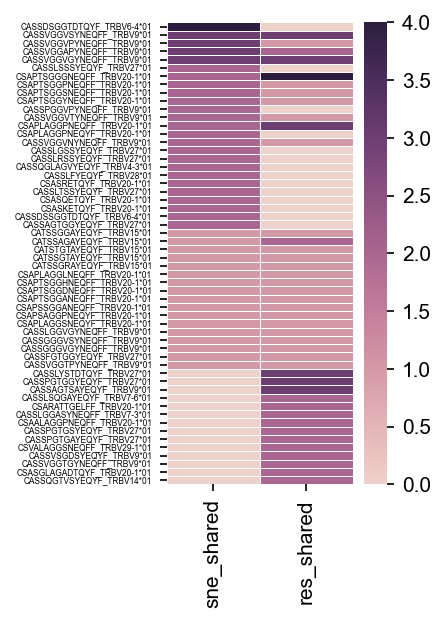

In [200]:
plt.rcParams['font.family'] = 'serif'  # Choose your preferred font family
plt.rcParams['font.serif'] = ['Arial']  # Use Times New Roman font
plt.rcParams['font.size'] = 10  # Adjust the font size as needed

data, annot = annotate_vdjdb(data=shared, vdjdb_index=index, vdjdb_annotations=vdjdb_annotations, r=24.5)
data = data[data.annotation.astype(str).str.contains('YFV')]

fig, ax = plt.subplots(figsize=(2,4),dpi=150)
sns.heatmap(
    data[['sne_shared','res_shared']],
    cmap=sns.cubehelix_palette(as_cmap=True),
    linewidths=.3,
    linecolor='white',
    yticklabels=data.clone)

yticks = ax.get_yticklabels()
ax.set_yticklabels(yticks, fontsize=4)
# ax.scatter(data.sne_shared, data.res_shared)

In [211]:
print(shared[shared.sne_shared>1].annotation.astype(str).str.contains('YFV').sum() / 254)
print(shared[shared.res_shared>1].annotation.astype(str).str.contains('YFV').sum() / 83)

0.0984251968503937
0.24096385542168675


In [54]:
responding = pd.read_table("../sne_manuscript/data/yfv_responding.txt")
responding = parse_responding(responding)


/tmp/ipykernel_2185725/3971178686.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["v_call"] = df["v_call"] + "*01"
/tmp/ipykernel_2185725/3971178686.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["j_call"] = df["j_call"] + "*01"
/tmp/ipykernel_2185725/3971178686.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/

junction_aa       v_call     
CSAPTSGGGNEQFF    TRBV20-1*01    4
CASSGTVYEQYF      TRBV28*01      4
CASSFYQETQYF      TRBV7-2*01     4
CASSVGGVSYNEQFF   TRBV9*01       3
CSAPLAGGPNEQFF    TRBV20-1*01    3
CASSLYSTDTQYF     TRBV27*01      3
CASSPGTGGYEQYF    TRBV27*01      3
CASSVGGVGYNEQFF   TRBV9*01       3
CASSAGTSAYEQYF    TRBV9*01       3
CASSSGTGAYEQYF    TRBV7-2*01     3
CSARDLRGTEAFF     TRBV20-1*01    2
CASSPGLARETQYF    TRBV7-2*01     2
CASSLGSTGELFF     TRBV5-1*01     2
CASSGDSAPTDTQYF   TRBV9*01       2
CASSLGGGGNTDTQYF  TRBV5-1*01     2
CASSEGYTGELFF     TRBV6-1*01     2
CASSLSQGAYEQYF    TRBV7-6*01     2
CASSEGTDAYEQYF    TRBV2*01       2
CASSLGGGDTQYF     TRBV5-1*01     2
CAISGQGPEAFF      TRBV10-3*01    2
CASSPATGAAYEQYF   TRBV27*01      2
CASSELNSPLHF      TRBV9*01       2
CSVPLAGGDNEQFF    TRBV29-1*01    2
CASSVATSGTYEQYF   TRBV9*01       2
CASSLGSGRTDTQYF   TRBV12-4*01    2
CSARATTGELFF      TRBV20-1*01    2
CSVPSGRDNEQFF     TRBV29-1*01    2
CASSFWADTQYF      TRBV7-2

24561 544
(24561, 544)


In [128]:
donor =  'S2'

sne_pre0 = pd.read_table(f"../sne_manuscript/analysis/yfv/updated/{donor}_pre0_F1_.txt.gz")
# sne_pre0["p_bf"] = multipletests(sne_pre0['pval'], method='bonferroni')[1]
# sne_pre0 = sne_pre0[sne_pre0.p_bf<.05]
rep_pre0 = parse_yfv_repertoires(f'../sne_manuscript/data/yfv/{donor}_pre0_F1_.txt.gz', count=1)
rep_pre0 = rep_pre0.merge(sne_pre0, on=['junction_aa','v_call'], how='left')
rep_pre0['pval'] = rep_pre0['pval'].fillna(1)
rep_pre0 = rep_pre0.sort_values(by='pval')
rep_pre0['pval_corr'] = multipletests(rep_pre0['pval'])[1]
rep_pre0 = rep_pre0[rep_pre0['pval_corr']<.05]

sne_15 = pd.read_table(f"../sne_manuscript/analysis/yfv/updated/{donor}_15_F1_.txt.gz")
# sne_15["p_bf"] = multipletests(sne_15['pval'], method='bonferroni')[1]
# sne_15 = sne_15[sne_15.p_bf<.05]
rep_15 = parse_yfv_repertoires(f'../sne_manuscript/data/yfv/{donor}_15_F1_.txt.gz')
rep_15 = rep_15.merge(sne_15, on=['junction_aa','v_call'], how='left')
rep_15['pval'] = rep_15['pval'].fillna(1)
rep_15 = rep_15.sort_values(by='pval')
rep_15['pval_corr'] = multipletests(rep_15['pval'])[1]
rep_15 = rep_15[rep_15['pval_corr']<.05]
# rep_pre0 = pd.read_table(f"../sne_manuscript/analysis/yfv/updated/{donor}_pre0_F1_.txt.gz")

/home/sebastiaan/miniconda3/envs/knn_tcr/lib/python3.9/site-packages/statsmodels/stats/multitest.py:186: RuntimeWarning:

divide by zero encountered in log1p

/home/sebastiaan/miniconda3/envs/knn_tcr/lib/python3.9/site-packages/statsmodels/stats/multitest.py:186: RuntimeWarning:

divide by zero encountered in log1p



In [143]:
data_15, annotations_15 = annotate_vdjdb(data=rep_15[['junction_aa','v_call']].drop_duplicates(), vdjdb_index=index, vdjdb_annotations=vdjdb_annotations)
n_annot_15 = data_15.annotation.astype(str).str.contains('YFV').sum()
print(n_annot_15, data_15.shape[0], n_annot_15/data_15.shape[0])

data_pre0, annotations_pre0 = annotate_vdjdb(data=rep_pre0[['junction_aa','v_call']].drop_duplicates(), vdjdb_index=index, vdjdb_annotations=vdjdb_annotations)
n_annot_pre0 = data_pre0.annotation.astype(str).str.contains('YFV').sum()
print(n_annot_pre0, data_pre0.shape[0], n_annot_pre0/data_pre0.shape[0])

encoding query sequences
231 544
(231, 544)
searching for neighbors
Combinding results
19 231 0.08225108225108226
encoding query sequences
274 544
(274, 544)
searching for neighbors
Combinding results
37 274 0.13503649635036497


## Longitudinal *LLWNGPMAV* annotation

Q1_pre0_F1_.txt.gz
encoding query sequences
searching for neighbors
Combining results
S2_pre0_F2_.txt.gz
encoding query sequences
searching for neighbors
Combining results
Q1_15_F1_.txt.gz
encoding query sequences
searching for neighbors
Combining results
Q2_pre0_F1_.txt.gz
encoding query sequences
searching for neighbors
Combining results
Q1_0_F1_.txt.gz
encoding query sequences
searching for neighbors
Combining results
P1_0_F1_.txt.gz
encoding query sequences
searching for neighbors
Combining results
S1_45_F1_.txt.gz
encoding query sequences
searching for neighbors
Combining results
S1_0_F1_.txt.gz
encoding query sequences
searching for neighbors
Combining results
S2_15_F2_.txt.gz
encoding query sequences
searching for neighbors
Combining results
P1_pre0_F1_.txt.gz
encoding query sequences
searching for neighbors
Combining results
S2_45_F1_.txt.gz
encoding query sequences
searching for neighbors
Combining results
Q2_0_F2_.txt.gz
encoding query sequences
searching for neighbors
Combin

/tmp/ipykernel_2367745/3895337689.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  donor_sub_1['b'] = donor_sub_1.b.map(tp_map)
/tmp/ipykernel_2367745/3895337689.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  donor_sub_2['b'] = donor_sub_2.b.map(tp_map)
/tmp/ipykernel_2367745/3895337689.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydat

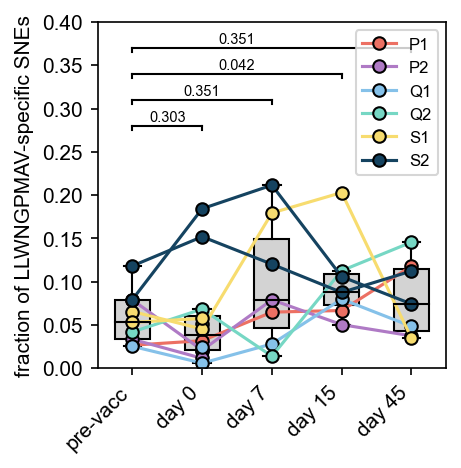

In [22]:
# Set up plotting aesthetics
donor_colors = {
    'P1':'#ec7063',
    'P2':'#af7ac5',
    'Q1':'#85c1e9',
    'Q2':'#76d7c4',
    'S1':'#f7dc6f',
    'S2':'#154360'
    }
plt.rcParams['font.family'] = 'serif'  # Choose your preferred font family
plt.rcParams['font.serif'] = ['Arial']  # Use Times New Roman font
plt.rcParams['font.size'] = 10  # Adjust the font size as needed

# Perform annotation
sne_files = os.listdir('../sne_manuscript/analysis/yfv/updated/')
results = []
for file in sne_files:
    print(file)
    donor, tp, rep, _ = file.split('_')
    sne = pd.read_table(f"../sne_manuscript/analysis/yfv/updated/{file}")
    sne["p_bf"] = multipletests(sne['pval'], method='bonferroni')[1]
    sne = sne[sne.p_bf<.05]
    sign, annotations = annotate_vdjdb(data=sne, vdjdb_index=index, vdjdb_annotations=vdjdb_annotations)
    total = sign.shape[0]
    annot_total = sign.annotation.dropna().shape[0]
    annot_yfv = sign.annotation.astype(str).str.contains('YFV').sum()
    results.append((donor,tp,rep,total,annot_total,annot_yfv))

# Combine results
res_df = pd.DataFrame(results, columns=['donor','timepoint','replicate','total_sne','annot_total','annot_yfv'])
res_df['yfv_sne_ratio'] = res_df.annot_yfv / res_df.total_sne

# Plot longitidunal data
timepoints = ['pre0','0','7','15','45']
bprop = {"facecolor":"lightgray"}
medprops = {"color":"black"}
fig, ax = plt.subplots(dpi=150, figsize=(3,3))
for n, tp in enumerate(timepoints):
    sub = res_df[res_df.timepoint==tp]
    data = sub.yfv_sne_ratio
    ax.boxplot(
        data,positions=[n],widths=.5,
        patch_artist=True,vert=True,boxprops=bprop,medianprops=medprops,
        showfliers=False
        )

# Add individual data points
res_df['b'] = pd.Categorical(res_df['timepoint'], categories=timepoints, ordered=True)
res_df = res_df.sort_values(by='b')
tp_map = {'pre0':0,'0':1,'7':2,'15':3,'45':4}

# and connect them (per donor)
donors = ['P1','P2','Q1','Q2','S1','S2']
for donor in donors:
    donor_sub = res_df[res_df.donor==donor]
    donor_sub_1 = donor_sub[donor_sub.replicate=='F1']
    donor_sub_1['b'] = donor_sub_1.b.map(tp_map)
    donor_sub_2 = donor_sub[donor_sub.replicate=='F2']
    donor_sub_2['b'] = donor_sub_2.b.map(tp_map)
    x1 = donor_sub_1.b
    y1 = donor_sub_1.yfv_sne_ratio
    x2 = donor_sub_2.b
    y2 = donor_sub_2.yfv_sne_ratio
    ax.plot(x1,y1,c=donor_colors[donor],marker='o',markeredgecolor='black',label=donor)
    ax.plot(x2,y2,c=donor_colors[donor],marker='o',markeredgecolor='black')

ax.legend(fontsize=8)
ax.set_xticklabels(['pre-vacc','day 0','day 7','day 15','day 45'], rotation=45, ha='right')
ax.set_ylabel('fraction of LLWNGPMAV-specific SNEs')
ax.set_ylim(0,0.40)

# Add p-value annotations
ax.plot([0,1],[0.28,0.28],c='black',lw=1)
ax.plot([0,0],[0.275,0.28],c='black',lw=1)
ax.plot([1,1],[0.275,0.28],c='black',lw=1)

S,p = mannwhitneyu(res_df[res_df.timepoint=='pre0'].yfv_sne_ratio,res_df[res_df.timepoint=='0'].yfv_sne_ratio)
ax.text(x=0.5,y=0.285,s=f'{p:.3f}',ha='center',fontsize=7)

ax.plot([0,2],[0.31,0.31],c='black',lw=1)
ax.plot([0,0],[0.305,0.31],c='black',lw=1)
ax.plot([2,2],[0.305,0.31],c='black',lw=1)
S,p = mannwhitneyu(res_df[res_df.timepoint=='pre0'].yfv_sne_ratio,res_df[res_df.timepoint=='7'].yfv_sne_ratio)
ax.text(x=1,y=0.315,s=f'{p:.3f}',ha='center',fontsize=7)

ax.plot([0,3],[0.34,0.34],c='black',lw=1)
ax.plot([0,0],[0.335,0.34],c='black',lw=1)
ax.plot([3,3],[0.335,0.34],c='black',lw=1)
S,p = mannwhitneyu(res_df[res_df.timepoint=='pre0'].yfv_sne_ratio,res_df[res_df.timepoint=='15'].yfv_sne_ratio)
ax.text(x=1.5,y=0.345,s=f'{p:.3f}',ha='center',fontsize=7)

ax.plot([0,4],[0.37,0.37],c='black',lw=1)
ax.plot([0,0],[0.365,0.37],c='black',lw=1)
ax.plot([4,4],[0.365,0.37],c='black',lw=1)
S,p = mannwhitneyu(res_df[res_df.timepoint=='pre0'].yfv_sne_ratio,res_df[res_df.timepoint=='45'].yfv_sne_ratio)
ax.text(x=1.5,y=0.375,s=f'{p:.3f}',ha='center',fontsize=7)

# Save figure
fig.savefig('../sne_manuscript/manuscript_figures/LLWNGPMAV_annotation.png',dpi=1000,format='png',bbox_inches='tight')

## **Create annotation networks**

In [ ]:
from plotly.offline import init_notebook_mode, iplot
from plotly.graph_objs import *

init_notebook_mode(connected=True)

def determine_legend(row):
    if row['responding'] and not row['yfv_annot']:
        return 'vaccine-responding'
    elif row['yfv_annot'] and not row['responding']:
        return 'YFV-specific'
    elif row['responding'] and row['yfv_annot']:
        return 'both'
    else:
        return None

def determine_legend_2(row):
    if row['legend'] == 'no annotation':
        if row['annotations'] != 'None':
            return 'other'
        else:
            return row['legend']
    else:
        return row['legend']

def create_annotated_network(sign, annotations, k=.1, iterations=50):

    nbr_df = neighbor_dict_to_df(neighbor_retrieval(sign, d=12.5))
    nbr_df = nbr_df[nbr_df.tcrdist>1]
    nodes = sign.v_call + "_" + sign.junction_aa
    edges = [(i,j) for i,j in zip(nbr_df['query'],nbr_df['background'])]

    sizes = []
    for i in nodes:
        if annotations[i] is not None:
            sizes.append(len(annotations[i])+1)
        else:
            sizes.append(1)

    G = nx.Graph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    pos = nx.spring_layout(G, k=k, iterations=iterations)
    node_x = [x for x, y in pos.values()]
    node_y = [-y for x, y in pos.values()]
    edge_x = [x for n0, n1 in G.edges for x in (pos[n0][0], pos[n1][0], None)]
    edge_y = [y for n0, n1 in G.edges for y in (-pos[n0][1], -pos[n1][1], None)]

    epitopes = [annotations[i] for i in nodes]
    data = {'node':nodes, 'xcoord':node_x, 'ycoord':node_y, 'annotations':epitopes}
    data = pd.DataFrame(data)
    data['annotations'] = data['annotations'].astype(str)

    data = data.merge(sign, left_on=['node'],right_on=['clone'])
    data['color'] = data.responding.map({True:'yellow', False:'grey'})

    data['n_annot'] = (data.annotation.apply(lambda x: x.count(',') + 1 if x != 'None' else 0) + 1)
    data['yfv_annot'] = data.annotation.str.contains('YFV')

    data['legend'] = data.apply(determine_legend, axis=1)
    data['legend'] = data.legend.fillna('no annotation')xcoord
    data['legend'] = data.apply(determine_legend_2, axis=1)

    return data, edge_x, edge_y, node_x, node_y


**Example for donor S1**

encoding query sequences
searching for neighbors
Combining results


/tmp/ipykernel_2367745/1215872643.py:39: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_2367745/1215872643.py:40: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_2367745/1215872643.py:41: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



encoding query sequences
building flat index
searching for neighbors
Combining results


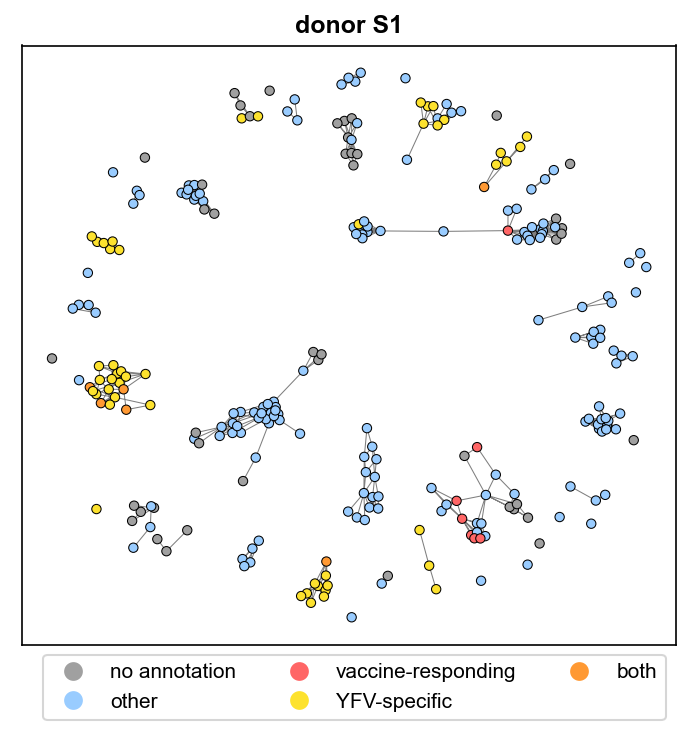

In [33]:
import ast

# Set font family and size
plt.rcParams['font.family'] = 'serif'  # Choose your preferred font family
plt.rcParams['font.serif'] = ['Arial']  # Use Times New Roman font
plt.rcParams['font.size'] = 10  # Adjust the font size as needed

# Prepare data
donor = "S1"
sne = pd.read_table(f'../sne_manuscript/analysis/yfv/updated/{donor}_15_F1_.txt.gz')
sne["p_bf"] = multipletests(sne['pval'], method='bonferroni')[1]
sne["p_bh"] = multipletests(sne['pval'], method='fdr_bh')[1]
sne = sne[sne.p_bf<.05]
sign, annotations = annotate_vdjdb(data=sne, vdjdb_index=index, vdjdb_annotations=vdjdb_annotations)
sign = merge_responding(data=sign, donor=donor)
sign, edge_x, edge_y, node_x, node_y = create_annotated_network(sign, annotations=annotations, k=.14, iterations=65)

# Assign colors to categories
color_annot = {
    'no annotation':'rgb(160,160,160)',
    'other':'rgb(153,204,255)',
    'vaccine-responding':'rgb(255,102,102)',
    'YFV-specific':'rgb(253,226,46)',
    'both':'rgb(255,153,51)'
    }
sign['color'] = sign.legend.map(color_annot)

# Plot network
fig, ax = plt.subplots(dpi=150, figsize=(5,5))

x = sign.xcoord
y = sign.ycoord
c = sign.color.apply(lambda x: ast.literal_eval(x[3:]))
c = c.apply(lambda x: tuple([i / 255 for i in x]))
ax.plot(edge_x,edge_y,c='black',alpha=.5,lw=.5,zorder=0)
ax.scatter(x,y,s=20,c=c,edgecolors='black',linewidths=0.5)

color_annot = {
    'no annotation':(0.6274509803921569, 0.6274509803921569, 0.6274509803921569),
    'other':(0.6, 0.8, 1.0),
    'vaccine-responding':(1.0, 0.4, 0.4),
    'YFV-specific':(0.9921568627450981, 0.8862745098039215, 0.1803921568627451),
    'both':(1.0, 0.6, 0.2)
    }

legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=label, markerfacecolor=color, markersize=10) for label, color in color_annot.items()]
ax.legend(handles=legend_elements, bbox_to_anchor=(1,0), ncol=3, fontsize=10)

ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f'donor {donor}', weight='bold')
fig.tight_layout()
# fig.savefig(f'../sne_manuscript/manuscript_figures/YFV_network_{donor}.png', format='PNG', dpi=1000)
# fig.savefig(f'../sne_manuscript/manuscript_figures/YFV_network_{donor}.pdf', format='pdf')


In [28]:
pre = res_df[res_df.timepoint=='pre0']
d0 = res_df[res_df.timepoint=='0']
d7 = res_df[res_df.timepoint=='7']
d15 = res_df[res_df.timepoint=='15']
d45 = res_df[res_df.timepoint=='45']

from scipy.stats import mannwhitneyu
print(mannwhitneyu(pre.annot_yfv/pre.annot_total,d15.annot_yfv/d15.annot_total))
print(mannwhitneyu(pre.annot_yfv/pre.annot_total,d0.annot_yfv/d0.annot_total))
print(mannwhitneyu(pre.annot_yfv/pre.annot_total,d7.annot_yfv/d7.annot_total))
print(mannwhitneyu(pre.annot_yfv/pre.annot_total,d45.annot_yfv/d45.annot_total))

MannwhitneyuResult(statistic=7.0, pvalue=0.007867132867132868)
MannwhitneyuResult(statistic=68.0, pvalue=0.3373556517763615)
MannwhitneyuResult(statistic=13.0, pvalue=0.0548951048951049)
MannwhitneyuResult(statistic=21.0, pvalue=0.29912587412587416)
